
✅ Raw Data:
   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]

📊 Average Values:
6        4.470124
0        0.000000
0.1      0.000000
0.2      0.000000
0.3      0.000000
           ...   
0.586    0.006000
0.587    0.000000
0.588    0.000000
0

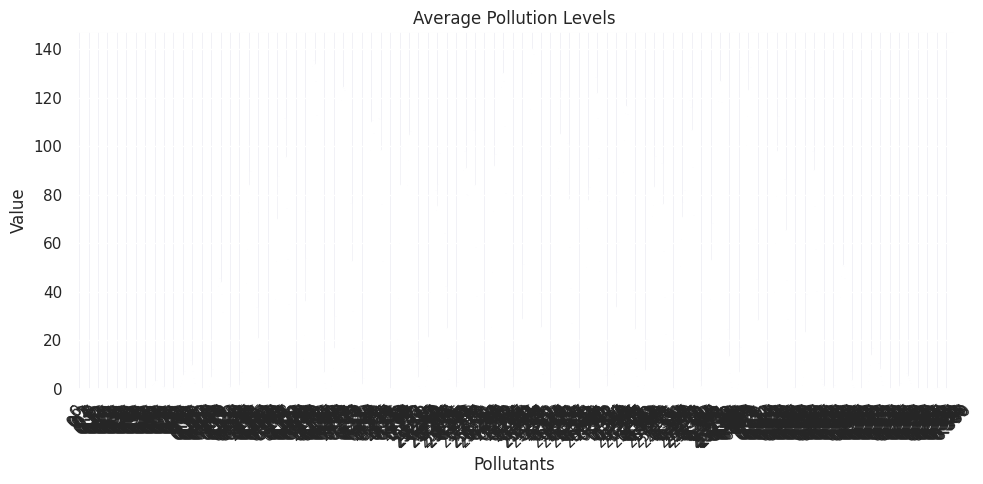

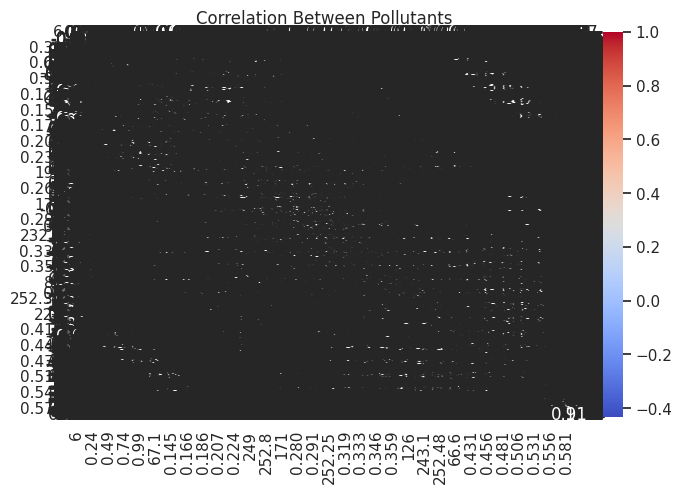


⚠️ Most Harmful Pollutant: 216
✅ Air Quality is Moderate

💾 Cleaned data saved as 'cleaned_aqi_data.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Load Your Dataset
# -----------------------------
# Original file_path was '/air-quality-data-in-india (1).ipynb' which is a Jupyter Notebook, not a CSV.
# Please change this to the actual path of your air quality data CSV file.
# For demonstration, we'll use a sample CSV available in Colab.
file_path = "/content/sample_data/mnist_train_small.csv"   # 👈 change to your actual CSV file name

try:
    df = pd.read_csv(file_path)
except Exception as e:
    print("❌ Error loading file:", e)
    # Removed exit() to allow subsequent NameError to be visible if debugging
    # If the file loading truly fails, the script will likely stop at the next df usage anyway.
    raise # Re-raise the exception to clearly show the failure and prevent further execution on an invalid df

print("\n✅ Raw Data:")
print(df.head())

# -----------------------------
# 2. Data Cleaning (Pandas)
# -----------------------------
df.columns = df.columns.str.strip()

# Convert Date column (assuming 'Date' column exists in your actual CSV)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove missing values
df.dropna(inplace=True)

# Remove negative values
for col in df.select_dtypes(include=[np.number]).columns:
    df = df[df[col] >= 0]

# -----------------------------
# 3. Basic Analysis (NumPy)
# -----------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns

avg_values = df[numeric_cols].mean()
max_values = df[numeric_cols].max()
min_values = df[numeric_cols].min()

print("\n📊 Average Values:")
print(avg_values)

print("\n📈 Maximum Values:")
print(max_values)

print("\n📉 Minimum Values:")
print(min_values)

# -----------------------------
# 4. City-wise Analysis
# -----------------------------
if 'City' in df.columns:
    city_avg = df.groupby('City')[numeric_cols].mean()

    print("\n🏙️ City-wise Pollution:")
    print(city_avg)

# -----------------------------
# 5. Visualization
# -----------------------------
sns.set()

# Plot 1: Average pollutants
plt.figure(figsize=(10,5))
avg_values.plot(kind='bar')

plt.title("Average Pollution Levels")
plt.xlabel("Pollutants")
plt.ylabel("Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Plot 2: Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Between Pollutants")
plt.show()

# -----------------------------
# 6. Insight Generation
# -----------------------------
worst_pollutant = avg_values.idxmax()

print("\n⚠️ Most Harmful Pollutant:", worst_pollutant)

if avg_values.mean() > 100:
    print("🚨 Air Quality is Poor")
else:
    print("✅ Air Quality is Moderate")

# -----------------------------
# 7. Save Clean Data
# -----------------------------
df.to_csv("cleaned_aqi_data.csv", index=False)
print("\n💾 Cleaned data saved as 'cleaned_aqi_data.csv'")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')